In [22]:
# ==========================================
# BLOQUE 1: IMPORTAR LIBRERÍAS Y CONFIGURACIÓN
# ==========================================
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as ipd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow.keras import layers, models

# Configuración general
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)


In [ ]:
# ==========================================
# BLOQUE 1.5: SOPORTE PARA MÚLTIPLES FORMATOS DE AUDIO
# ==========================================

"""
📁 FORMATOS DE AUDIO SOPORTADOS:
- .wav (sin dependencias adicionales)
- .mp3 (requiere ffmpeg o audioread)
- .flac
- .ogg
- .m4a

🔧 INSTALACIÓN DE DEPENDENCIAS PARA MP3:

Opción 1 - FFmpeg (RECOMENDADO):
  Ubuntu/Debian:  sudo apt-get install ffmpeg
  macOS:          brew install ffmpeg
  Windows:        Descargar desde https://ffmpeg.org/

Opción 2 - Audioread:
  pip install audioread

Librosa usará automáticamente ffmpeg o audioread si están disponibles.

💡 VERIFICACIÓN:
"""

import subprocess
import sys

def check_audio_support():
    """Verifica qué formatos de audio están soportados"""
    print("🔍 Verificando soporte de audio...\n")
    
    # Verificar ffmpeg
    try:
        result = subprocess.run(['ffmpeg', '-version'], 
                              capture_output=True, 
                              text=True, 
                              timeout=5)
        if result.returncode == 0:
            print("✅ FFmpeg instalado - Todos los formatos soportados (.mp3, .wav, .flac, etc.)")
            return True
    except (FileNotFoundError, subprocess.TimeoutExpired):
        print("⚠️ FFmpeg NO encontrado")
    
    # Verificar audioread
    try:
        import audioread
        print("✅ audioread instalado - Soporte para .mp3")
        return True
    except ImportError:
        print("❌ audioread NO instalado")
    
    print("\n⚠️ ADVERTENCIA: Solo archivos .wav serán procesados correctamente")
    print("   Para MP3 y otros formatos, instala ffmpeg o audioread")
    print("\n   Instalación rápida de ffmpeg:")
    print("   - Linux: sudo apt-get install ffmpeg")
    print("   - macOS: brew install ffmpeg")
    print("   - Windows: https://ffmpeg.org/download.html")
    
    return False

check_audio_support()

In [24]:
# ==========================================
# BLOQUE 2: DEFINIR RUTAS Y CLASES
# ==========================================

# Ruta base (ajústala si tus audios están en otra carpeta)
DATA_PATH = "./audios"

# Clases o categorías de edad
CLASSES = ["Niño", "Adolescente", "Juvenil", "Adulto", "Adulto_mayor"]

# Verificar estructura de carpetas
for c in CLASSES:
    folder = os.path.join(DATA_PATH, c)
    if not os.path.exists(folder):
        print(f"⚠️ Falta carpeta: {folder}")
    else:
        print(f"✅ Carpeta detectada: {folder}")


✅ Carpeta detectada: ./audios/Niño
✅ Carpeta detectada: ./audios/Adolescente
✅ Carpeta detectada: ./audios/Juvenil
✅ Carpeta detectada: ./audios/Adulto
✅ Carpeta detectada: ./audios/Adulto_mayor


In [25]:
# ==========================================
# BLOQUE 3: PREPROCESAMIENTO Y FEATURES
# ==========================================

def extract_features(file_path, n_mfcc=40, max_len=173):
    """
    Extrae MFCCs promedio de un archivo de audio.
    Retorna un vector 1D (promedio por coeficiente).
    """
    try:
        audio, sr = librosa.load(file_path, sr=22050)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        mfcc = np.mean(mfcc.T, axis=0)
        return mfcc
    except Exception as e:
        print("Error con archivo:", file_path, "-", e)
        return None


In [ ]:
# ==========================================
# BLOQUE 4: CARGAR AUDIOS Y EXTRAER MFCCs
# ==========================================

features = []
labels = []

# Formatos de audio soportados
AUDIO_FORMATS = ('.wav', '.mp3', '.flac', '.ogg', '.m4a')

for label in CLASSES:
    folder = os.path.join(DATA_PATH, label)
    if not os.path.exists(folder):
        continue
    
    audio_count = 0
    for file in os.listdir(folder):
        # Verificar si el archivo tiene una extensión de audio soportada
        if file.lower().endswith(AUDIO_FORMATS):
            path = os.path.join(folder, file)
            data = extract_features(path)
            if data is not None:
                features.append(data)
                labels.append(label)
                audio_count += 1
    
    print(f"✅ {label}: {audio_count} archivos procesados")

X = np.array(features)
y = np.array(labels)

print("\n" + "=" * 50)
print(f"📊 Shape de X: {X.shape}")
print(f"📊 Cantidad total de muestras: {len(y)}")
print("=" * 50)

In [27]:
# ==========================================
# BLOQUE 5: DIVISIÓN DE DATOS
# ==========================================

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Clases codificadas:", le.classes_)


Clases codificadas: ['Adolescente' 'Adulto' 'Adulto_mayor' 'Juvenil' 'Niño']


In [28]:
# ==========================================
# BLOQUE 6: RANDOM FOREST
# ==========================================

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy Random Forest:", accuracy_score(y_test, y_pred_rf))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_rf, target_names=le.classes_))


Accuracy Random Forest: 0.9916666666666667

Reporte de clasificación:
               precision    recall  f1-score   support

 Adolescente       1.00      0.96      0.98        24
      Adulto       1.00      1.00      1.00        24
Adulto_mayor       1.00      1.00      1.00        24
     Juvenil       0.96      1.00      0.98        24
        Niño       1.00      1.00      1.00        24

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



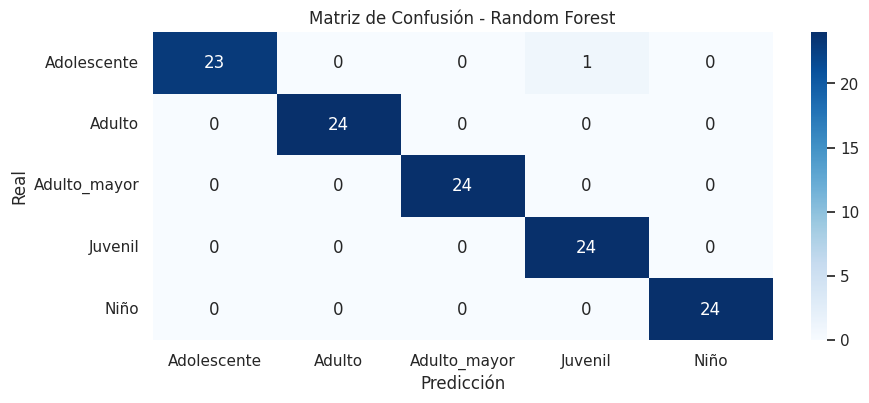

In [29]:
# ==========================================
# BLOQUE 7: MATRIZ DE CONFUSIÓN
# ==========================================

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


In [ ]:
# ==========================================
# BLOQUE 8: CNN CON ESPECTROGRAMAS
# ==========================================

def audio_to_melspectrogram(file_path, img_size=(128, 128)):
    """
    Convierte un archivo de audio a mel-spectrogram.
    Soporta múltiples formatos: .wav, .mp3, .flac, .ogg, .m4a
    """
    y, sr = librosa.load(file_path, sr=22050)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = librosa.util.fix_length(mel_db, size=img_size[1], axis=1)
    mel_db = mel_db[:img_size[0], :]
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min())
    return mel_db

# Crear dataset visual
X_img, y_img = [], []

for label in CLASSES:
    folder = os.path.join(DATA_PATH, label)
    if not os.path.exists(folder):
        continue
    
    for file in os.listdir(folder):
        # Soportar múltiples formatos de audio
        if file.lower().endswith(AUDIO_FORMATS):
            path = os.path.join(folder, file)
            try:
                mel = audio_to_melspectrogram(path)
                X_img.append(mel)
                y_img.append(label)
            except Exception as e:
                print(f"Error procesando {file}: {e}")

X_img = np.array(X_img)
y_img = np.array(y_img)

# Adaptar para CNN
X_img = X_img[..., np.newaxis]
y_img_enc = le.fit_transform(y_img)

X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_img, y_img_enc, test_size=0.2, random_state=42, stratify=y_img_enc
)

print(f"Shape espectrogramas: {X_train_img.shape}")
print(f"Total de muestras para CNN: {len(X_img)}")

In [31]:
# ==========================================
# BLOQUE 9: MODELO CNN SIMPLE
# ==========================================

cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(CLASSES), activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = cnn.fit(
    X_train_img, y_train_img,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


/home/david/Documentos/estudios/2025-2 ITM/EII/venv-eii/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 301ms/step - accuracy: 0.5651 - loss: 1.3454 - val_accuracy: 1.0000 - val_loss: 0.2463
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 270ms/step - accuracy: 0.9974 - loss: 0.0587 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 275ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step - accuracy: 1.0000 - loss: 5.8402e-04 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 1.0000 - loss: 3.4714e-04 - val_accuracy: 1.0000 - val_loss: 7.5153e-04
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 1.0000 - loss: 2.7260e-04 - val_accuracy: 1.0000 - val_loss: 6.6679e-04
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - accuracy: 1.0000 - loss: 2.2256e-04 - val_accuracy: 1.0000 - val_loss: 6.0449e-04
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step - accuracy: 1.0000 - lo

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step
Accuracy CNN: 1.0

Reporte de clasificación:
               precision    recall  f1-score   support

 Adolescente       1.00      1.00      1.00        24
      Adulto       1.00      1.00      1.00        24
Adulto_mayor       1.00      1.00      1.00        24
     Juvenil       1.00      1.00      1.00        24
        Niño       1.00      1.00      1.00        24

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



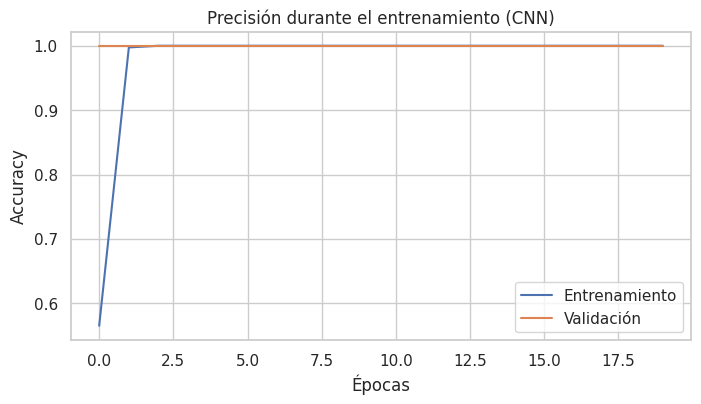

In [32]:
# ==========================================
# BLOQUE 10: EVALUACIÓN Y VISUALIZACIÓN
# ==========================================

y_pred_cnn = np.argmax(cnn.predict(X_test_img), axis=1)
print("Accuracy CNN:", accuracy_score(y_test_img, y_pred_cnn))
print("\nReporte de clasificación:\n", classification_report(y_test_img, y_pred_cnn, target_names=le.classes_))

# Curvas de entrenamiento
plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title("Precisión durante el entrenamiento (CNN)")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


💡 Función de predicción lista para usar!

Ejemplos de uso:
  predict_audio_all_models('./audios/Niño/audio_001.wav')
  predict_audio_all_models('./ruta/a/tu/audio.wav')

🔍 Probando con: ./audios/tests/F1_01_02.wav

🎤 PREDICCIÓN DE EDAD PARA: F1_01_02.wav

📊 MODELO 1: Random Forest (MFCCs)
--------------------------------------------------------------------------------
🎯 Predicción: Niño
📈 Confianza: 61.00%

   Probabilidades por clase:
   Adolescente     [13.00%] █████
   Adulto          [ 3.50%] █
   Adulto_mayor    [20.50%] ████████
   Juvenil         [ 2.00%] 
   Niño            [61.00%] ████████████████████████


📊 MODELO 2: CNN (Mel-spectrogramas)
--------------------------------------------------------------------------------
🎯 Predicción: Adulto_mayor
📈 Confianza: 65.84%

   Probabilidades por clase:
   Adolescente     [ 0.02%] 
   Adulto          [27.01%] ██████████
   Adulto_mayor    [65.84%] ██████████████████████████
   Juvenil         [ 2.35%] 
   Niño            [ 4.78%] █

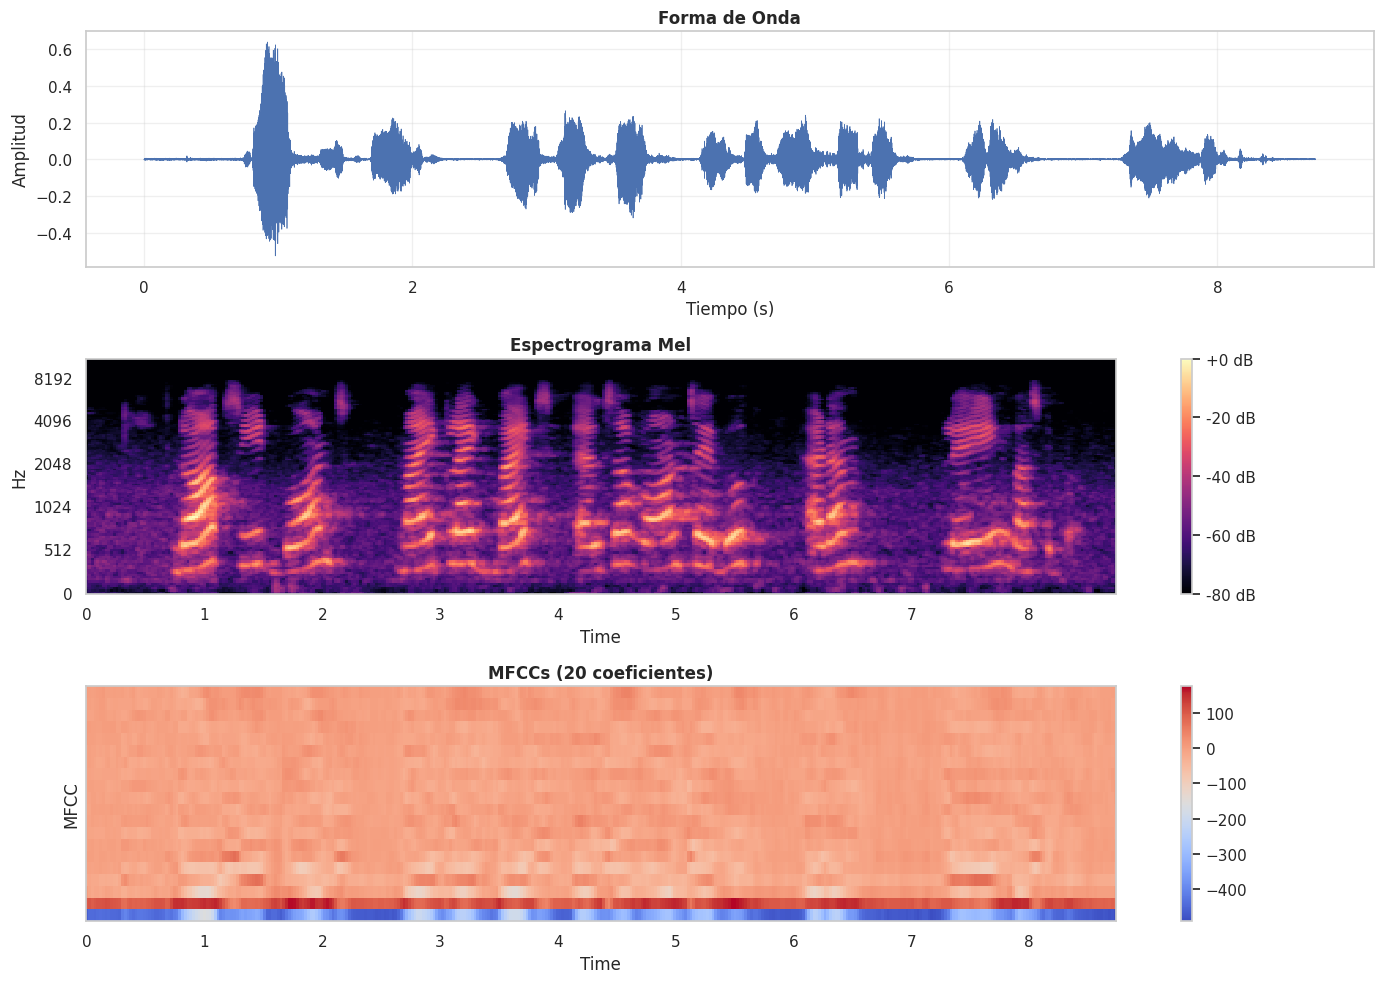


🔊 Reproducir audio:



✅ Análisis completado


In [35]:
# ==========================================
# BLOQUE EXTRA: PRUEBA CON AUDIO NUEVO
# ==========================================

def predict_audio_all_models(audio_path):
    """
    Predice el rango de edad usando TODOS los modelos disponibles
    y muestra una comparación completa de resultados.
    """
    if not os.path.exists(audio_path):
        print(f"❌ Error: No se encontró el archivo {audio_path}")
        return
    
    print("=" * 80)
    print(f"🎤 PREDICCIÓN DE EDAD PARA: {os.path.basename(audio_path)}")
    print("=" * 80)
    
    # ========== MODELO 1: Random Forest (MFCCs) ==========
    print("\n📊 MODELO 1: Random Forest (MFCCs)")
    print("-" * 80)
    try:
        mfcc_features = extract_features(audio_path)
        if mfcc_features is not None:
            mfcc_features = mfcc_features.reshape(1, -1)
            pred_rf = rf.predict(mfcc_features)[0]
            pred_rf_proba = rf.predict_proba(mfcc_features)[0]
            
            print(f"🎯 Predicción: {le.classes_[pred_rf]}")
            print(f"📈 Confianza: {pred_rf_proba[pred_rf]*100:.2f}%")
            print("\n   Probabilidades por clase:")
            for i, (clase, prob) in enumerate(zip(le.classes_, pred_rf_proba)):
                bar = "█" * int(prob * 40)
                print(f"   {clase:15s} [{prob*100:5.2f}%] {bar}")
    except Exception as e:
        print(f"❌ Error: {e}")
    
    # ========== MODELO 2: CNN (Mel-spectrogramas) ==========
    print("\n\n📊 MODELO 2: CNN (Mel-spectrogramas)")
    print("-" * 80)
    try:
        mel_spec = audio_to_melspectrogram(audio_path)
        mel_spec_input = mel_spec[np.newaxis, ..., np.newaxis]
        
        pred_cnn = cnn.predict(mel_spec_input, verbose=0)
        pred_cnn_class = np.argmax(pred_cnn[0])
        
        print(f"🎯 Predicción: {le.classes_[pred_cnn_class]}")
        print(f"📈 Confianza: {pred_cnn[0][pred_cnn_class]*100:.2f}%")
        print("\n   Probabilidades por clase:")
        for i, (clase, prob) in enumerate(zip(le.classes_, pred_cnn[0])):
            bar = "█" * int(prob * 40)
            print(f"   {clase:15s} [{prob*100:5.2f}%] {bar}")
    except Exception as e:
        print(f"❌ Error: {e}")
    
    # ========== MODELO 3: Transfer Learning (YAMNet) - Si existe ==========
    print("\n\n📊 MODELO 3: Transfer Learning (YAMNet)")
    print("-" * 80)
    try:
        # Verificar si existe el modelo YAMNet
        if 'model_yamnet' in globals() and 'extract_yamnet_embeddings' in globals():
            embedding = extract_yamnet_embeddings(audio_path, apply_augmentation=False)
            if embedding is not None:
                embedding_input = embedding.reshape(1, -1)
                pred_yamnet = model_yamnet.predict(embedding_input, verbose=0)
                pred_yamnet_class = np.argmax(pred_yamnet[0])
                
                print(f"🎯 Predicción: {le.classes_[pred_yamnet_class]}")
                print(f"📈 Confianza: {pred_yamnet[0][pred_yamnet_class]*100:.2f}%")
                print("\n   Probabilidades por clase:")
                for i, (clase, prob) in enumerate(zip(le.classes_, pred_yamnet[0])):
                    bar = "█" * int(prob * 40)
                    print(f"   {clase:15s} [{prob*100:5.2f}%] {bar}")
        else:
            print("⚠️ Modelo YAMNet no disponible (ejecuta los bloques de Transfer Learning primero)")
    except Exception as e:
        print(f"❌ Error: {e}")
    
    # ========== VISUALIZACIÓN DEL AUDIO ==========
    print("\n\n🎵 VISUALIZACIÓN DEL AUDIO")
    print("=" * 80)
    
    # Cargar audio
    y, sr = librosa.load(audio_path, sr=22050)
    
    # Crear figura con 3 subplots
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # 1. Forma de onda
    axes[0].plot(np.linspace(0, len(y)/sr, len(y)), y, linewidth=0.5)
    axes[0].set_title('Forma de Onda', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Tiempo (s)')
    axes[0].set_ylabel('Amplitud')
    axes[0].grid(True, alpha=0.3)
    
    # 2. Espectrograma Mel
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img1 = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1])
    axes[1].set_title('Espectrograma Mel', fontsize=12, fontweight='bold')
    fig.colorbar(img1, ax=axes[1], format='%+2.0f dB')
    
    # 3. MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    img2 = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=axes[2])
    axes[2].set_title('MFCCs (20 coeficientes)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('MFCC')
    fig.colorbar(img2, ax=axes[2])
    
    plt.tight_layout()
    plt.show()
    
    # Reproducir audio (si estás en Jupyter)
    print("\n🔊 Reproducir audio:")
    display(ipd.Audio(audio_path))
    
    print("\n" + "=" * 80)
    print("✅ Análisis completado")
    print("=" * 80)


# ========== EJEMPLO DE USO ==========
print("💡 Función de predicción lista para usar!")
print("\nEjemplos de uso:")
print("  predict_audio_all_models('./audios/Niño/audio_001.wav')")
print("  predict_audio_all_models('./ruta/a/tu/audio.wav')")

# Prueba automática si existe un archivo de test
test_file = "./audios/tests/F1_01_02.wav"
if os.path.exists(test_file):
    print(f"\n🔍 Probando con: {test_file}\n")
    predict_audio_all_models(test_file)
else:
    # Buscar el primer audio disponible para probar
    for clase in CLASSES:
        folder = os.path.join(DATA_PATH, clase)
        if os.path.exists(folder):
            archivos = [f for f in os.listdir(folder) if f.endswith('.wav')]
            if archivos:
                primer_audio = os.path.join(folder, archivos[0])
                print(f"\n🔍 Probando con el primer audio encontrado: {primer_audio}\n")
                predict_audio_all_models(primer_audio)
                break